<a href="https://colab.research.google.com/github/keswong/phd_listing_repo/blob/main/3_7_1_Statistical_Analysis_Between_Scaffoldings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Statistical test for significant differences in Pretest**

Section 3.4.2 Formation of Triads using Pretest

In [ ]:
%reset -f
from scipy.stats import zscore
import pandas as pd
import pingouin as pg

file_path = '.../ Log_Data.xlsx'
df_original = pd.read_excel(file_path, sheet_name='Log_Data')

df = df_original[df_original['School'] == "Sec3"]
df = df[df['Pretest'].notnull() & df['Posttest'].notnull()]
df['Pretest_1_Zscore'] = zscore(df['Pretest_1'])
df['Pretest_2_Zscore'] = zscore(df['Pretest_2'])
df['Pretest_3_Zscore'] = zscore(df['Pretest_3'])
df['Pretest_4_Zscore'] = zscore(df['Pretest_4'])
df['Pretest_5_Zscore'] = zscore(df['Pretest_5'])

pretest_cols = ['Pretest_1_Zscore', 'Pretest_2_Zscore', 'Pretest_3_Zscore', 'Pretest_4_Zscore', 'Pretest_5_Zscore']
pretest_data = df[pretest_cols].dropna()

# Compute Cronbach's Alpha
alpha, p = pg.cronbach_alpha(pretest_data)

print(f"Cronbach's Alpha: {alpha:.6f}")
if alpha >= 0.9:
    print("Excellent reliability (α ≥ 0.9)")
elif alpha >= 0.8:
    print("Good reliability (0.8 ≤ α < 0.9)")
elif alpha >= 0.7:
    print("Acceptable reliability (0.7 ≤ α < 0.8)")
elif alpha >= 0.6:
    print("Questionable reliability (0.6 ≤ α < 0.7)")
elif alpha >= 0.5:
    print("Poor reliability (0.5 ≤ α < 0.6)")
else:
    print("Unacceptable reliability (α < 0.5)")


Cronbach's Alpha: 0.443499
Unacceptable reliability (α < 0.5)


In [ ]:
%reset -f
import pandas as pd
from scipy.stats import shapiro

file_path = '.../ Log_Data.xlsx'
df_original = pd.read_excel(file_path, sheet_name='Log_Data')

df = df_original[df_original['School'] == "Sec3"]

stat, p_value = shapiro(df['Pretest'])
print(f'Shapiro-Wilk test statistic: {stat:.4f}, p-value: {p_value:.4f}')

Shapiro-Wilk test statistic: 0.9273, p-value: 0.0003


In [ ]:
# @title
%reset -f
import pingouin as pg
import pandas as pd

# Read the data
file_path = '.../ Log_Data.xlsx'
df_original = pd.read_excel(file_path, sheet_name='Log_Data')

# Filter data for 'Sec3' school and non-null Pretest & Posttest values
df = df_original[df_original['School'] == "Sec3"]
unique_students = df['STUDENT_INDEX'].nunique()

group1 = df[df['Intervention'] == 'Scaffolding']['Pretest']
group2 = df[df['Intervention'] == 'No Scaffolding']['Pretest']
size = group1.size + group2.size
print(f'Total number of students who took pre-test: {size}')
mwu_results = pg.mwu(x=group1, y=group2,alternative='two-sided')
print(mwu_results)
mwu_results = pg.mwu(x=group1, y=group2,alternative='greater')
print(mwu_results)

Total number of students who took pre-test: 78
     U-val alternative     p-val       RBC      CLES
MWU  793.0   two-sided  0.745147  0.042735  0.521368
     U-val alternative     p-val       RBC      CLES
MWU  793.0     greater  0.372574  0.042735  0.521368


# **Statistical test for significant differences in Posttest_5 between Scaffolding and No Scaffolding**

3.7.1 Statistical Analysis of Performance Improvement and Indicators

In [ ]:
pip install pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 13.4 MB/s eta 0:00:00


In [ ]:
%reset -f
import pandas as pd
from scipy.stats import shapiro
import pingouin as pg

file_path = '.../ Log_Data.xlsx'
df_original = pd.read_excel(file_path, sheet_name='Log_Data')

df = df_original[df_original['School'] == "Sec3"]
df = df[df['Pretest'].notnull() & df['Posttest'].notnull()]
df['diff'] = df['Posttest_5'] - df['Pretest_5']

stat, p_value = shapiro(df['diff'])
print(f'Shapiro-Wilk test statistic: {stat:.4f}, p-value: {p_value:.4e}')
print("=====================================================")
unique_students = df['STUDENT_INDEX'].nunique()
print(f'Total number of students: {unique_students}')
improved = (df['diff'] > 0).sum()
declined = (df['diff'] < 0).sum()
same = (df['diff'] == 0).sum()
improvement_counts = df[df['diff'] > 0]['diff'].value_counts().sort_index()
print(f"Improved: {improved}")
print(f"Declined: {declined}")
print(f"No change: {same}")

improvement_df = improvement_counts.reset_index()
improvement_df.columns = ['Improvement Amount', 'Count']
print(improvement_df)
print("=====================================================")
wilcoxon_results = pg.wilcoxon(x=df['Posttest_5'], y=df['Pretest_5'],alternative='two-sided')
print(wilcoxon_results)
wilcoxon_results = pg.wilcoxon(x=df['Posttest_5'], y=df['Pretest_5'],alternative='greater')
print(wilcoxon_results)

Shapiro-Wilk test statistic: 0.5109, p-value: 2.1970e-13
Total number of students: 65
Improved: 14
Declined: 0
No change: 51
   Improvement Amount  Count
0                 1.0      3
1                 2.0      2
2                 3.0      2
3                 4.0      7
          W-val alternative     p-val  RBC      CLES
Wilcoxon    0.0   two-sided  0.000915  1.0  0.607692
          W-val alternative     p-val  RBC      CLES
Wilcoxon  105.0     greater  0.000458  1.0  0.607692


In [ ]:
%reset -f
import pingouin as pg
import pandas as pd

file_path = '.../Log_Data.xlsx'
df_original = pd.read_excel(file_path, sheet_name='Log_Data')

df = df_original[df_original['School'] == "Sec3"]
df = df[df['Pretest'].notnull() & df['Posttest'].notnull()]
unique_students = df['STUDENT_INDEX'].nunique()

group1 = df[df['Intervention'] == 'Scaffolding']['Posttest_5']
group2 = df[df['Intervention'] == 'No Scaffolding']['Posttest_5']
size = group1.size + group2.size
print(f'Total number of students who completed both pre-test and post-test: {size}')
mwu_results = pg.mwu(x=group1, y=group2,alternative='two-sided')
print(mwu_results)
mwu_results = pg.mwu(x=group1, y=group2,alternative='greater')
print(mwu_results)

Total number of students who completed both pre-test and post-test: 65
     U-val alternative     p-val       RBC     CLES
MWU  626.0   two-sided  0.065534  0.192381  0.59619
     U-val alternative     p-val       RBC     CLES
MWU  626.0     greater  0.032767  0.192381  0.59619


# **Multilevel analysis of scaffolding condition**
3.7.1 Statistical Analysis of Performance Improvement and Indicators

In [ ]:
%reset -f
import pandas as pd
import statsmodels.formula.api as smf

file_path = '.../Log_Data.xlsx'
df_original = pd.read_excel(file_path, sheet_name='Log_Data')
df = df_original[df_original['School'] == "Sec3"]
df = df[df['Pretest_5'].notnull() & df['Posttest_5'].notnull()]

m_full = smf.mixedlm(
    "Posttest_5 ~ 1",       # Intervention = between-triad condition
    df,
    groups=df["Group"],             # random intercept for triads
    re_formula="1",
    vc_formula={"STUDENT_INDEX": "0 + C(STUDENT_INDEX)"}  # random intercept for participants
).fit(reml=True)

In [ ]:
%reset -f
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

file_path = '.../Log_Data.xlsx'
df_original = pd.read_excel(file_path, sheet_name='Log_Data')
df = df_original[df_original['School'] == "Sec3"]
df = df[df['Pretest_5'].notnull() & df['Posttest_5'].notnull()]

m_null = smf.mixedlm(
    "Posttest_5 ~ 1",
    df,
    groups=df["Group"]
).fit(reml=True)
print(m_null.summary())

var_group = m_null.cov_re.iloc[0, 0]
var_resid = m_null.scale

ICC = var_group / (var_group + var_resid)
ICC_adj = round(ICC, 4) * 100
print(f"The ICC shows that {ICC_adj}% of the variance in Posttest_5 can be explained by the membership in a triad.")

m_1 = smf.mixedlm(
    "Posttest_5 ~ Intervention",
    df,
    groups=df["Group"]
).fit(reml=True)
print(m_1.summary())

print(f"There are no significant main-effects of intervention when using minimal scaffold as the baseline.")

var_group = m_1.cov_re.iloc[0, 0]  # Random intercept variance (between-group)
var_resid = m_1.scale              # Residual variance (within-group)

deviance_m_null = -2 * m_null.llf
deviance_m1 = -2 * m_1.llf
print(f"m_null deviance = {deviance_m_null}")
print(f"m1_deviance = {deviance_m1}")

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Posttest_5
No. Observations: 65      Method:             REML      
No. Groups:       26      Scale:              1.4626    
Min. group size:  1       Log-Likelihood:     -110.7085 
Max. group size:  3       Converged:          Yes       
Mean group size:  2.5                                   
---------------------------------------------------------
            Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
---------------------------------------------------------
Intercept   0.623     0.191  3.270  0.001   0.250   0.997
Group Var   0.340     0.263                              

The ICC shows that 18.86% of the variance in Posttest_5 can be explained by the membership in a triad.
               Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     Posttest_5
No. Observations:     65          Method:                 REML      
No. Groups:           26  

# **Analysis of triads with at least two group members with performance improvements**

Figure 4.1

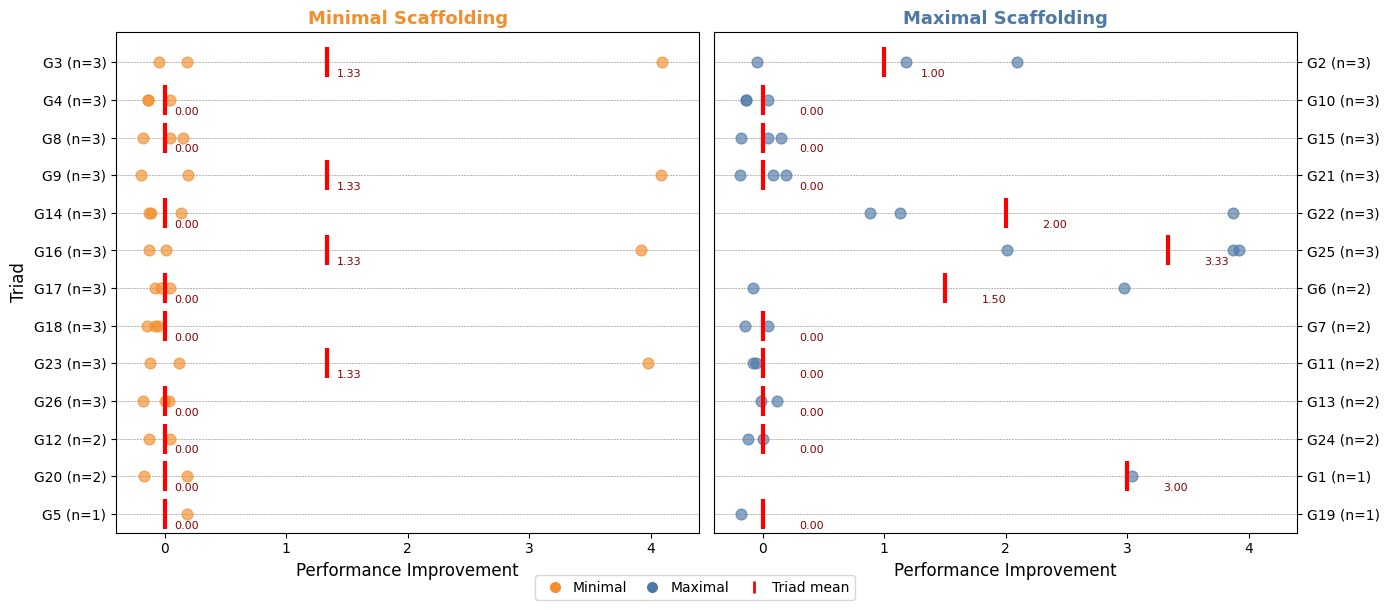

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

file_path = ".../Individual Improvement.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")

df = df.dropna(subset=["Performance Improvement"])
df["Group_Num"] = df["Group"].str.extract(r"(\d+)").astype(int)

group_summary = (
    df.groupby(["Intervention", "Group", "Group_Num"])
      .size()
      .reset_index(name="n_students")
)

def get_sorted_triads(intervention):
    subset = group_summary[group_summary["Intervention"] == intervention]
    subset = subset.sort_values(
        by=["n_students", "Group_Num"],
        ascending=[False, True]
    )
    return subset["Group"].tolist()

minimal_triads = get_sorted_triads("Minimal")
maximal_triads = get_sorted_triads("Maximal")


max_len = max(len(minimal_triads), len(maximal_triads))
minimal_triads_padded = minimal_triads + [None] * (max_len - len(minimal_triads))
maximal_triads_padded = maximal_triads + [None] * (max_len - len(maximal_triads))

group_counts = df.groupby("Group").size()

fig, (ax_min, ax_max) = plt.subplots(
    1, 2,
    figsize=(14, 6),
    sharey=False
)

color_map = {
    "Maximal": "#4E79A7",
    "Minimal": "#F28E2B"
}

def plot_side(ax, triads_padded, intervention, color, mirror=False):
    np.random.seed(42)

    for i, triad in enumerate(triads_padded):
        if triad is None:
            continue

        triad_data = df[df["Group"] == triad]["Performance Improvement"]

        # Jitter
        x_vals = triad_data.values + np.random.uniform(-0.2, 0.2, size=len(triad_data))

        ax.scatter(
            x_vals,
            [i] * len(x_vals),
            alpha=0.65,
            s=60,
            color=color,
            zorder=3
        )

        # Triad mean
        mean_val = triad_data.mean()
        ax.plot(
            [mean_val], [i],
            marker="|",
            color="red",
            markersize=22,
            markeredgewidth=3,
            linestyle="None",
            zorder=4
        )


        if mirror:
            offset = 0.3
            ha = "left"
        else:
            offset = 0.08
            ha = "left"
        ax.text(
            mean_val + offset, i + 0.18,
            f"{mean_val:.2f}",
            color="darkred",
            fontsize=8,
            ha=ha,
            va="top"
        )

        ax.axhline(y=i, color="grey", linewidth=0.4, linestyle="--", zorder=1)

plot_side(ax_min, minimal_triads_padded, "Minimal",  color_map["Minimal"],  mirror=False)
plot_side(ax_max, maximal_triads_padded, "Maximal", color_map["Maximal"], mirror=True)

ax_min.set_yticks(range(max_len))
ax_min.set_yticklabels([
    f"{t} (n={group_counts[t]})" if t else ""
    for t in minimal_triads_padded
])
ax_min.invert_yaxis()

ax_min.set_ylim(max_len - 0.5, -0.8)
ax_max.set_ylim(max_len - 0.5, -0.8)

ax_min.set_xlim(-0.4, 4.4)
ax_max.set_xlim(-0.4, 4.4)  # Mirror x-axis for right panel

ax_min.set_title("Minimal Scaffolding", fontsize=13, color=color_map["Minimal"], fontweight="bold")
ax_max.set_title("Maximal Scaffolding", fontsize=13, color=color_map["Maximal"], fontweight="bold")

ax_min.set_xlabel("Performance Improvement", fontsize=12)
ax_max.set_xlabel("Performance Improvement", fontsize=12)
ax_min.set_ylabel("Triad", fontsize=12)

ax_max.set_yticks(range(max_len))
ax_max.set_yticklabels([
    f"{t} (n={group_counts[t]})" if t else ""
    for t in maximal_triads_padded
])
ax_max.yaxis.set_label_position("right")
ax_max.yaxis.tick_right()
ax_max.tick_params(axis="y", which="both", left=False, right=True, labelright=True)

triad_mean_handle = Line2D(
    [0], [0],
    color="red",
    marker="|",
    linestyle="None",
    markersize=9,
    markeredgewidth=2,
    label="Triad mean"
)

minimal_handle = Line2D([0], [0], marker="o", color="w",
                         markerfacecolor=color_map["Minimal"],
                         markersize=9, label="Minimal")
maximal_handle = Line2D([0], [0], marker="o", color="w",
                         markerfacecolor=color_map["Maximal"],
                         markersize=9, label="Maximal")

fig.legend(
    handles=[minimal_handle, maximal_handle, triad_mean_handle],
    loc="lower center",
    ncol=3,
    fontsize=10,
    bbox_to_anchor=(0.5, -0.02),
    handletextpad=0.3,
    columnspacing=0.8,
    labelspacing=0.2,
)

plt.tight_layout()
plt.show()

In [ ]:
%reset -f
import pandas as pd
from scipy.stats import fisher_exact


file_path = '.../Log_Data.xlsx'
df_original = pd.read_excel(file_path, sheet_name='Log_Data')
sec3_all = df_original[df_original['School'] == "Sec3"]
sec3_filtered = sec3_all[sec3_all['Pretest'].notnull() & sec3_all['Posttest'].notnull()]
df = sec3_filtered

group_counts = df['Group'].value_counts()

df['gain'] = (df['Posttest_5'] > df['Pretest_5']).astype(int)

group_counts = df['Group'].value_counts()
valid_groups = group_counts[group_counts >= 2].index
excluded_groups = group_counts[group_counts < 2].index
num_excluded = len(excluded_groups)
print(f'Excluded groups: {num_excluded}')

interventions = df.drop_duplicates(subset='Group').set_index('Group')['Intervention']
interventions_for_excluded = interventions.loc[excluded_groups].reset_index()

excluded_df = pd.DataFrame({
    'Group': interventions_for_excluded['Group'],
    'Intervention': interventions_for_excluded['Intervention'],
    'outcome': 0
})

print(excluded_df)

group_filtered = df[df['Group'].isin(valid_groups)]
df = group_filtered

group_summary = df.groupby(['Group', 'Intervention'], as_index=False)['gain'].mean()
group_summary['outcome'] = (group_summary['gain'] >= 0.5).astype(int)
outcome_df = group_summary[['Group', 'Intervention', 'outcome']]
print(outcome_df)


df = outcome_df
contingency = pd.crosstab(df['Intervention'], df['outcome'])
print("Contingency table:\n", contingency)

# Fisher's Exact Test
oddsratio, p_value = fisher_exact(contingency)
print(f"\nOdds ratio = {oddsratio:.4f}, p-value = {p_value:.4f}")

contingency = pd.crosstab(df['Intervention'], df['outcome'])
print("Contingency table:\n", contingency)

risk = contingency.div(contingency.sum(axis=1), axis=0)[1]
print("\nRisk (proportion of successes) per group:\n", risk)

# Compute risk difference and risk ratio
risk_diff = risk.iloc[0] - risk.iloc[1]
risk_ratio = risk.iloc[0] / risk.iloc[1] if risk.iloc[1] != 0 else float('inf')

print(f"\nRisk difference (Group1 - Group2) = {risk_diff:.4f}")
print(f"Risk ratio (Group1 / Group2) = {risk_ratio:.4f}")

Excluded groups: 3
  Group    Intervention  outcome
0    G1     Scaffolding        0
1    G5  No Scaffolding        0
2   G19     Scaffolding        0
   Group    Intervention  outcome
0    G10     Scaffolding        0
1    G11     Scaffolding        0
2    G12  No Scaffolding        0
3    G13     Scaffolding        0
4    G14  No Scaffolding        0
5    G15     Scaffolding        0
6    G16  No Scaffolding        0
7    G17  No Scaffolding        0
8    G18  No Scaffolding        0
9     G2     Scaffolding        1
10   G20  No Scaffolding        0
11   G21     Scaffolding        0
12   G22     Scaffolding        1
13   G23  No Scaffolding        0
14   G24     Scaffolding        0
15   G25     Scaffolding        1
16   G26  No Scaffolding        0
17    G3  No Scaffolding        0
18    G4  No Scaffolding        0
19    G6     Scaffolding        1
20    G7     Scaffolding        0
21    G8  No Scaffolding        0
22    G9  No Scaffolding        0
Contingency table:
 outcome      

/tmp/ipykernel_5863/3428242264.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['gain'] = (df['Posttest_5'] > df['Pretest_5']).astype(int)


Inclusion of the three excluded triads that only had one
student with completed pretest and post-test scores

In [ ]:
%reset -f
import pandas as pd
from scipy.stats import fisher_exact

file_path = '.../Log_Data.xlsx'
df_original = pd.read_excel(file_path, sheet_name='Log_Data')
sec3_all = df_original[df_original['School'] == "Sec3"]
sec3_filtered = sec3_all[sec3_all['Pretest'].notnull() & sec3_all['Posttest'].notnull()]
df = sec3_filtered

group_counts = df['Group'].value_counts()
df['gain'] = (df['Posttest_5'] > df['Pretest_5']).astype(int)

group_summary = df.groupby(['Group', 'Intervention'], as_index=False)['gain'].mean()
group_summary['outcome'] = (group_summary['gain'] >= 0.5).astype(int)
outcome_df = group_summary[['Group', 'Intervention', 'outcome']]
print(outcome_df)

df = outcome_df
contingency = pd.crosstab(df['Intervention'], df['outcome'])
print("Contingency table:\n", contingency)

# Fisher's Exact Test
oddsratio, p_value = fisher_exact(contingency)
print(f"\nOdds ratio = {oddsratio:.4f}, p-value = {p_value:.4f}")

contingency = pd.crosstab(df['Intervention'], df['outcome'])
print("Contingency table:\n", contingency)

risk = contingency.div(contingency.sum(axis=1), axis=0)[1]
print("\nRisk (proportion of successes) per group:\n", risk)

risk_diff = risk.iloc[0] - risk.iloc[1]
risk_ratio = risk.iloc[0] / risk.iloc[1] if risk.iloc[1] != 0 else float('inf')

print(f"\nRisk difference (Group1 - Group2) = {risk_diff:.4f}")
print(f"Risk ratio (Group1 / Group2) = {risk_ratio:.4f}")

   Group    Intervention  outcome
0     G1     Scaffolding        1
1    G10     Scaffolding        0
2    G11     Scaffolding        0
3    G12  No Scaffolding        0
4    G13     Scaffolding        0
5    G14  No Scaffolding        0
6    G15     Scaffolding        0
7    G16  No Scaffolding        0
8    G17  No Scaffolding        0
9    G18  No Scaffolding        0
10   G19     Scaffolding        0
11    G2     Scaffolding        1
12   G20  No Scaffolding        0
13   G21     Scaffolding        0
14   G22     Scaffolding        1
15   G23  No Scaffolding        0
16   G24     Scaffolding        0
17   G25     Scaffolding        1
18   G26  No Scaffolding        0
19    G3  No Scaffolding        0
20    G4  No Scaffolding        0
21    G5  No Scaffolding        0
22    G6     Scaffolding        1
23    G7     Scaffolding        0
24    G8  No Scaffolding        0
25    G9  No Scaffolding        0
Contingency table:
 outcome          0  1
Intervention         
No Scaffolding  13

/tmp/ipython-input-2799274721.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['gain'] = (df['Posttest_5'] > df['Pretest_5']).astype(int)


# **Distribution of indicators**

Figure 4.2, Figure 4.3, and Figure 4.4.

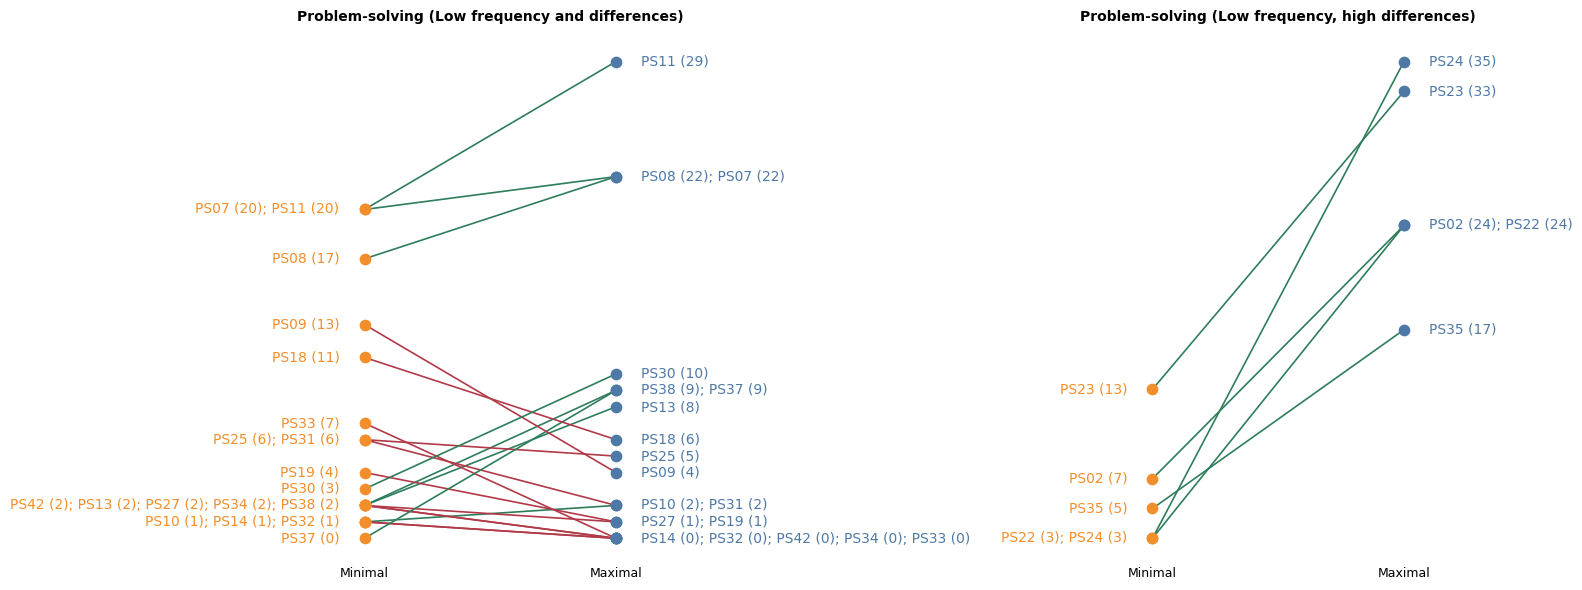

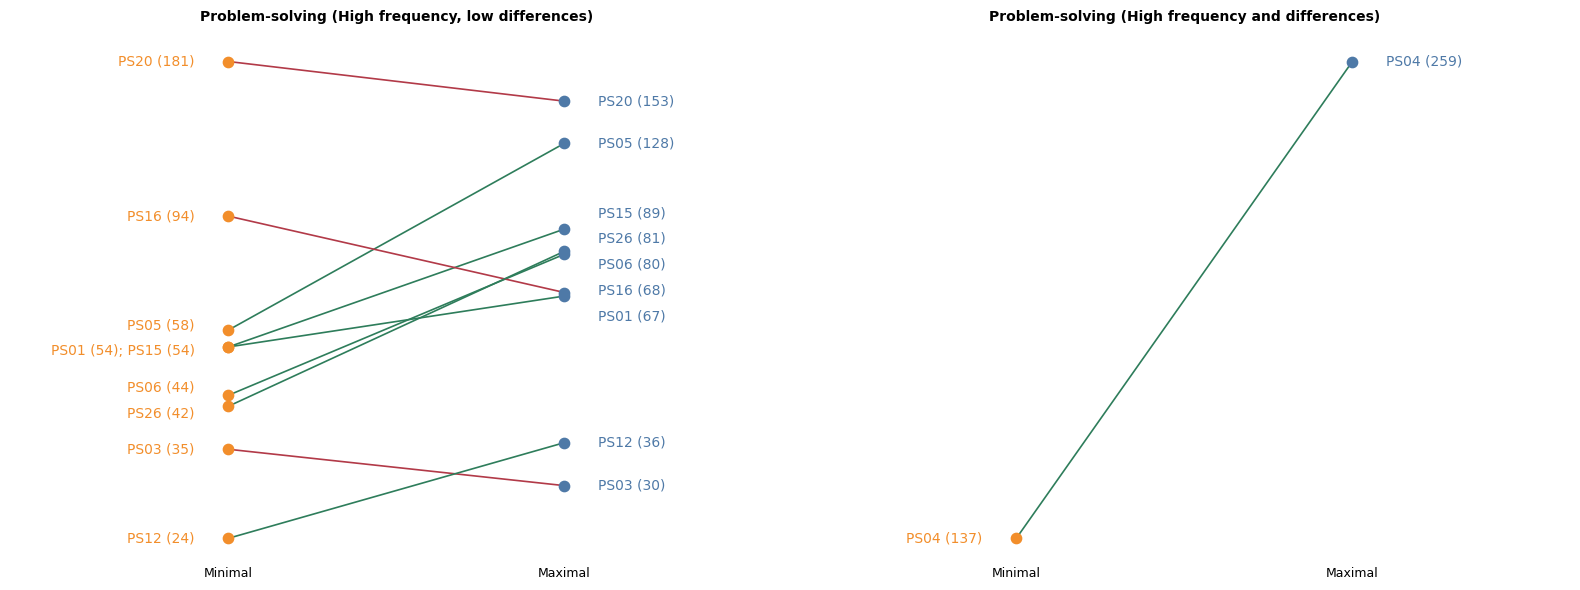

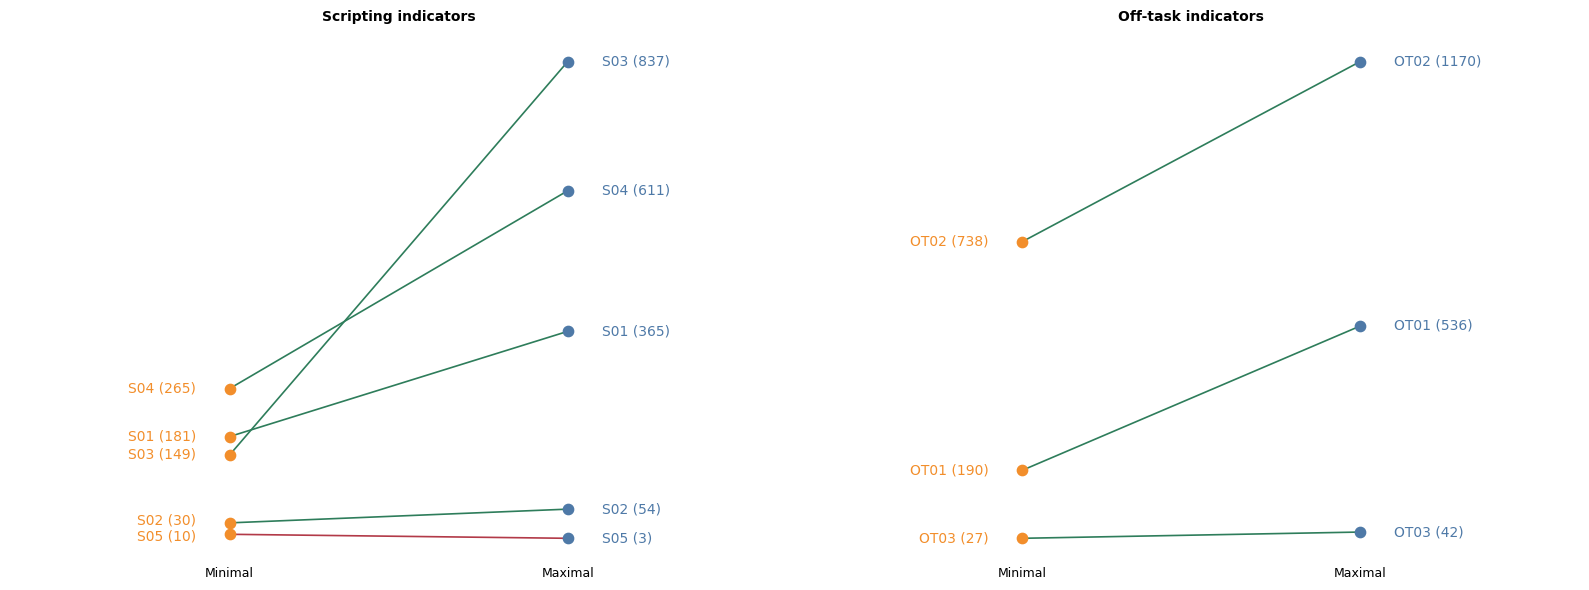

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

PS_LOW = [
    ("PS10", 1, 2), ("PS14", 1, 0), ("PS32", 1, 0), ("PS42", 2, 0),
    ("PS13", 2, 8), ("PS27", 2, 1), ("PS34", 2, 0),
    ("PS38", 2, 9),
    ("PS19", 4, 1), ("PS25", 6, 5), ("PS31", 6, 2),
    ("PS33", 7, 0), ("PS37", 0, 9),
    ("PS09", 13, 4), ("PS18", 11, 6), ("PS30", 3, 10),
    ("PS08", 17, 22), ("PS07", 20, 22), ("PS11", 20, 29),
]

PS_MID = [
    ("PS02", 7, 24), ("PS35", 5, 17),
    ("PS22", 3, 24), ("PS23", 13, 33),
    ("PS24", 3, 35),
]

PS_HIGH = [
    ("PS01", 54, 67), ("PS03", 35, 30),
    ("PS05", 58, 128), ("PS06", 44, 80),
    ("PS12", 24, 36), ("PS15", 54, 89),
    ("PS16", 94, 68), ("PS26", 42, 81), ("PS20", 181, 153)
]

PS_EXTREME = [
    ("PS04", 137, 259),
]

S = [
    ("S01", 181, 365), ("S02", 30, 54),
    ("S03", 149, 837), ("S04", 265, 611),
    ("S05", 10, 3)
]

OT = [
    ("OT01", 190, 536), ("OT02", 738, 1170), ("OT03", 27, 42),
]

# ============================================================
# STYLE
# ============================================================
BLUE = "#4E79A7"
ORANGE = "#F28E2B"
UP_COLOR = "#2E7D5B"
DOWN_COLOR = "#B23A48"

DOT_SIZE = 55
LEFT_X = -0.1
RIGHT_X = 1.1

# ============================================================
# FUNCTIONS
# ============================================================

def group_labels(labels, values):
    groups = {}
    for v, lbl in zip(values, labels):
        key = round(v, 6)
        if key not in groups:
            groups[key] = {"labels": [], "val": v}
        groups[key]["labels"].append(lbl)
    result = []
    for key in sorted(groups):
        g = groups[key]
        combined = "; ".join(f"{lbl} ({int(key)})" for lbl in g["labels"])
        result.append((key, combined))
    return result


def spread_labels(values, y_min, y_max, min_gap_frac=0.035):
    n = len(values)
    if n == 0:
        return values
    min_gap = (y_max - y_min) * min_gap_frac
    order = np.argsort(values)
    pos = np.array(values, dtype=float)[order]
    for _ in range(2000):
        moved = False
        for i in range(1, n):
            if pos[i] - pos[i - 1] < min_gap:
                overlap = min_gap - (pos[i] - pos[i - 1])
                pos[i - 1] -= overlap / 2
                pos[i] += overlap / 2
                moved = True
        if not moved:
            break
    result = np.empty(n)
    for rank, orig_idx in enumerate(order):
        result[orig_idx] = pos[rank]
    return result


# ============================================================
# PLOTTING CORE
# ============================================================

def plot_slope(ax, data, title, log_scale=False):

    all_vals = [v for _, ns, s in data for v in [ns, s] if v > 0]
    y_min_data = min(all_vals) if all_vals else 1
    y_max_data = max(max(ns, s) for _, ns, s in data)

    labels = [d[0] for d in data]
    ns_vals = np.array([d[1] for d in data], dtype=float)
    s_vals  = np.array([d[2] for d in data], dtype=float)

    if log_scale:
        # Clamp zeros to a small positive value so log works
        ns_plot = np.where(ns_vals > 0, ns_vals, 0.5)
        s_plot  = np.where(s_vals  > 0, s_vals,  0.5)
        ax.set_yscale("log")
        y_min_spread = np.log10(max(y_min_data * 0.5, 0.5))
        y_max_spread = np.log10(y_max_data * 1.5)
        # label positions in log space
        ns_label_vals = np.log10(np.where(ns_vals > 0, ns_vals, 0.5))
        s_label_vals  = np.log10(np.where(s_vals  > 0, s_vals,  0.5))
    else:
        ns_plot = ns_vals
        s_plot  = s_vals
        y_min_spread = 0
        y_max_spread = y_max_data
        ns_label_vals = ns_vals
        s_label_vals  = s_vals

    # Lines + dots
    for (label, ns, s), ns_p, s_p in zip(data, ns_plot, s_plot):
        color = UP_COLOR if s >= ns else DOWN_COLOR
        ax.plot([0, 1], [ns_p, s_p],
                color=color, linewidth=1.2, alpha=1, zorder=1)
        ax.scatter([0], [ns_p], color=ORANGE, s=DOT_SIZE, zorder=2)
        ax.scatter([1], [s_p],  color=BLUE,   s=DOT_SIZE, zorder=3)

    # LEFT labels
    ns_groups = group_labels(labels, ns_label_vals)
    ns_pos    = [g[0] for g in ns_groups]
    ns_spread = spread_labels(ns_pos, y_min_spread, y_max_spread)

    for (orig_log, text), spread_log in zip(ns_groups, ns_spread):
        y_text = 10**spread_log if log_scale else spread_log
        orig_val = int(round(10**orig_log)) if log_scale else int(round(orig_log))
        display = "; ".join(
            f"{part.split(' (')[0]} ({orig_val})"
            for part in text.split("; ")
        )
        ax.text(LEFT_X, y_text, display,
                ha="right", va="center", fontsize=10, color=ORANGE)

    # RIGHT labels
    s_groups = group_labels(labels, s_label_vals)
    s_pos    = [g[0] for g in s_groups]
    s_spread = spread_labels(s_pos, y_min_spread, y_max_spread)

    for (orig_log, text), spread_log in zip(s_groups, s_spread):
        y_text = 10**spread_log if log_scale else spread_log
        orig_val = int(round(10**orig_log)) if log_scale else int(round(orig_log))
        display = "; ".join(
            f"{part.split(' (')[0]} ({orig_val})"
            for part in text.split("; ")
        )
        ax.text(RIGHT_X, y_text, display,
                ha="left", va="center", fontsize=10, color=BLUE)

    ax.set_xlim(-0.65, 1.65)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Minimal", "Maximal"], fontsize=9)
    ax.tick_params(axis="x", length=0)
    ax.yaxis.set_visible(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_title(title, fontsize=10, fontweight="semibold", pad=12)


# ============================================================
# FIGURE 1 — PS LOW + MID
# ============================================================

fig1, axes1 = plt.subplots(1, 2, figsize=(16, 6))

plot_slope(axes1[0], PS_LOW, "Problem-solving (Low frequency and differences)")
plot_slope(axes1[1], PS_MID, "Problem-solving (Low frequency, high differences)")

plt.tight_layout()
plt.show()


# ============================================================
# FIGURE 2 — PS HIGH + EXTREME
# ============================================================

fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))

plot_slope(axes2[0], PS_HIGH, "Problem-solving (High frequency, low differences)", log_scale=True)
plot_slope(axes2[1], PS_EXTREME, "Problem-solving (High frequency and differences)")

plt.tight_layout()
plt.show()


# ============================================================
# FIGURE 3 — S + OT
# ============================================================

fig3, axes3 = plt.subplots(1, 2, figsize=(16, 6))

plot_slope(axes3[0], S, "Scripting indicators")
plot_slope(axes3[1], OT, "Off-task indicators")

plt.tight_layout()
plt.show()

# **Pearson's chi-square tests of homogeneity comparing the proportion of indicators between maximal and minimal scaffolding condition**

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

file_path = '.../Coding_Data.xlsx'
df = pd.read_excel(file_path, sheet_name='Dataset')

df["Codebook_Cognitive"] = df["Codebook_Cognitive"].astype(str).str.split(",")
df = df.explode("Codebook_Cognitive")
df["Codebook_Cognitive"] = df["Codebook_Cognitive"].str.strip()

df = df.dropna(subset=['INTERVENTION', 'Codebook_Cognitive'])
df = df[
    ~df['Codebook_Cognitive'].str.lower().isin(['nan', 'na', 'n/a', 'none', ''])
]
df['INTERVENTION'] = df['INTERVENTION'].astype(str).str.strip()

def map_cat(code):
    if code.startswith("CP"):
        return "scripting"
    elif code.startswith("SC"):
        return "problem_solving"
    elif code.startswith("OT"):
        return "off_task"
    else:
        return "unknown"

df["Category"] = df["Codebook_Cognitive"].apply(map_cat)

condition_map = {
    "Scaffolding":    "Maximal",
    "No Scaffolding": "Minimal"
}
df["Condition"] = df["INTERVENTION"].map(condition_map)
df = df.dropna(subset=["Condition"])

omnibus_counts = (
    df[df["Category"] != "unknown"]
    .groupby(["Category", "Condition"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["Maximal", "Minimal"], fill_value=0)
)

chi2_om, p_om, dof_om, expected_om = chi2_contingency(omnibus_counts)
n_total_om = omnibus_counts.values.sum()
cramers_v_om = np.sqrt(chi2_om / (n_total_om * (min(omnibus_counts.shape) - 1)))

print(f"\n{'='*50}")
print(f"  OMNIBUS 3x2 CHI-SQUARE TEST")
print(f"{'='*50}")
print("\nObserved counts:")
print(omnibus_counts)
print(f"\nChi2       = {chi2_om:.4f}")
print(f"df         = {dof_om}")
print(f"p-value    = {p_om:.2e}")
print(f"Cramér's V = {cramers_v_om:.4f}")

comparisons = {
    "Problem Solving": "problem_solving",
    "Scripting":       "scripting",
    "Off-Task":        "off_task",
}

results = {}

for label, target_cat in comparisons.items():

    df["Binary"] = df["Category"].apply(
        lambda x: label if x == target_cat else f"Non-{label}"
    )

    counts = (
        df.groupby(["Condition", "Binary"])
          .size()
          .unstack(fill_value=0)
          .reindex(index=["Maximal", "Minimal"],
                   columns=[label, f"Non-{label}"],
                   fill_value=0)
    )

    proportions = counts.div(counts.sum(axis=1), axis=0)

    chi2, p, dof, expected = chi2_contingency(counts)
    expected_df = pd.DataFrame(expected, index=counts.index, columns=counts.columns)

    n_total = counts.values.sum()
    cramers_v = np.sqrt(chi2 / (n_total * (min(counts.shape) - 1)))

    results[label] = {
        "chi2": chi2,
        "p": p,
        "dof": dof,
        "cramers_v": cramers_v,
        "counts": counts,
        "proportions": proportions,
        "expected": expected_df,
    }

    print(f"\n{'='*50}")
    print(f"  FOLLOW-UP: {label}")
    print(f"{'='*50}")
    print("\nObserved counts:")
    print(counts)
    print("\nProportions within each condition:")
    print(proportions.round(4))
    print(f"\nExpected counts:")
    print(expected_df.round(2))
    print(f"\nChi2       = {chi2:.4f}")
    print(f"df         = {dof}")
    print(f"p-value    = {p:.2e}")
    print(f"p-value    = {p:.10f}")
    print(f"Cramér's V = {cramers_v:.4f}")


n_tests = len(results)
alpha   = 0.05
alpha_corrected = alpha / n_tests

print(f"\n{'='*50}")
print(f"  BONFERRONI CORRECTION (n tests = {n_tests})")
print(f"  Adjusted α = {alpha} / {n_tests} = {alpha_corrected:.4f}")
print(f"{'='*50}")

summary_rows = []
for label, res in results.items():
    p_raw  = res["p"]
    p_bonf = min(p_raw * n_tests, 1.0)
    sig    = "Significant" if p_bonf < alpha else "Not Significant"
    summary_rows.append({
        "Category":    label,
        "Chi2":        round(res["chi2"], 4),
        "df":          res["dof"],
        "p (raw)":     f"{p_raw:.3e}",        # scientific notation
        "p (exact)":   f"{p_raw:.3e}",       # 10 decimal places
        "p (Bonf.)":   f"{p_bonf:.3e}",
        "Cramér's V":  round(res["cramers_v"], 4),
        "Significant": sig
    })

summary_df = pd.DataFrame(summary_rows).set_index("Category")
print("\nSummary table:")
print(summary_df.to_string())


  OMNIBUS 3x2 CHI-SQUARE TEST

Observed counts:
Condition        Maximal  Minimal
Category                         
off_task            1748      955
problem_solving     1254      874
scripting           1870      635

Chi2       = 133.3314
df         = 2
p-value    = 1.12e-29
Cramér's V = 0.1348

  FOLLOW-UP: Problem Solving

Observed counts:
Binary     Problem Solving  Non-Problem Solving
Condition                                      
Maximal               1254                 3618
Minimal                874                 1590

Proportions within each condition:
Binary     Problem Solving  Non-Problem Solving
Condition                                      
Maximal             0.2574               0.7426
Minimal             0.3547               0.6453

Expected counts:
Binary     Problem Solving  Non-Problem Solving
Condition                                      
Maximal            1413.25              3458.75
Minimal             714.75              1749.25

Chi2       = 74.7869
d

# **Wilcoxon signed rank test to compare the time on scripting/problem solving between maximal and minimal scaffolding conditions**

Mean PS utterance time (minutes): 1.6962975238095241
Mean S utterance time (minutes): 1.473958715596326


/tmp/ipykernel_5439/744164344.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x="Group", y="Utterance_seconds",
/tmp/ipykernel_5439/744164344.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


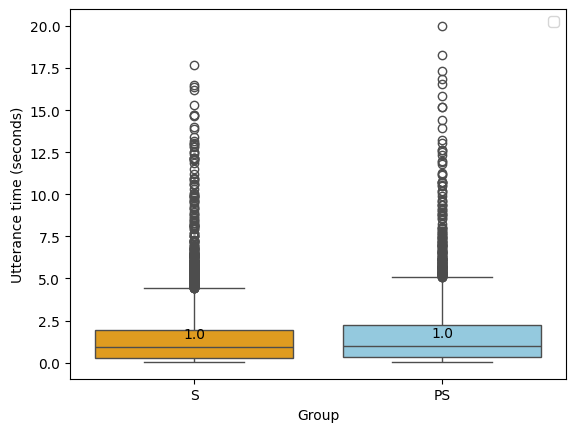

In [ ]:
%reset -f
from scipy.stats import zscore
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

file_path = '.../Coding_Data.xlsx'
df = pd.read_excel(file_path, sheet_name='Dataset')
df = df_original[df_original['LEVEL'] == "SEC3"]
df_zoom = df[df["Type"] == "Zoom_Audio"].copy()

df_zoom["Utterance_seconds"] = df_zoom["Utterance Duration"]

ps_mean = df_zoom.loc[df_zoom["PS"] == 1, "Utterance_seconds"].mean()
s_mean = df_zoom.loc[df_zoom["S"] == 1, "Utterance_seconds"].mean()

print("Mean PS utterance time (minutes):", ps_mean)
print("Mean S utterance time (minutes):", s_mean)

df_zoom["Group"] = None
df_zoom.loc[df_zoom["PS"] == 1, "Group"] = "PS"
df_zoom.loc[df_zoom["S"] == 1, "Group"] = "S"

df_plot = df_zoom[df_zoom["Group"].notna()]


sns.boxplot(data=df_plot, x="Group", y="Utterance_seconds",
            palette={"PS": "skyblue", "S": "orange"})

ps_median = df_plot.loc[df_plot["Group"] == "PS", "Utterance_seconds"].median()
s_median = df_plot.loc[df_plot["Group"] == "S", "Utterance_seconds"].median()

plt.text(1, ps_median + 0.5, f"{ps_median:.1f}", color="black", ha="center")
plt.text(0, s_median + 0.5, f"{s_median:.1f}", color="black", ha="center")

plt.ylabel("Utterance time (seconds)")
plt.legend()
plt.show()

In [ ]:
df_zoom = df[df["Type"] == "Zoom_Audio"].copy()
df_zoom["Utterance_seconds"] = df_zoom["Utterance Duration"]

group_stats = df_zoom.groupby("Group").apply(
    lambda g: pd.Series({
        "Total_seconds": g["Utterance_seconds"].sum(),
        "PS_seconds": g.loc[g["PS"] == 1, "Utterance_seconds"].sum(),
        "S_seconds": g.loc[g["S"] == 1, "Utterance_seconds"].sum(),
        "PS_mean": g.loc[g["PS"] == 1, "Utterance_seconds"].mean(),
        "S_mean": g.loc[g["S"] == 1, "Utterance_seconds"].mean()
    })
).reset_index()
print(group_stats)

   Group  Total_seconds  PS_seconds  S_seconds   PS_mean    S_mean
0     G1        329.762     170.531    157.057  1.291902  0.892369
1    G10        543.244     221.551    318.360  1.172228  1.113147
2    G11          1.700       0.000      0.130       NaN  0.065000
3    G12          3.093       0.000      2.803       NaN  2.803000
4    G13       1388.848     327.557   1060.093  1.482158  1.254548
5    G14        475.194      49.064    406.152  1.090311  1.106681
6    G15       1100.372       6.593   1089.128  1.648250  1.463882
7    G16       1586.693     862.418    717.425  1.887129  1.938986
8    G17          1.360       0.000      0.000       NaN       NaN
9    G18          6.723       2.773      1.660  0.924333  1.660000
10   G19          2.019       0.000      0.000       NaN       NaN
11    G2        643.202      40.241    520.215  1.257531  1.287661
12   G21          2.747       0.000      1.635       NaN  1.635000
13   G22        893.901     272.503    616.044  1.651533  1.45

/tmp/ipykernel_5439/1067328574.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_stats = df_zoom.groupby("Group").apply(


In [ ]:
from scipy.stats import shapiro

group_means_clean = group_stats

stat, p_ps = shapiro(group_means_clean["PS_seconds"])
print(f"PS_seconds: W={stat:.3f}, p={p_ps:.3f}")

stat, p_s = shapiro(group_means_clean["S_seconds"])
print(f"S_seconds: W={stat:.3f}, p={p_s:.3f}")

ttest_res = pg.ttest(
    group_means_clean["S_seconds"],
    group_means_clean["PS_seconds"],
    paired=False,
    alternative='greater'
)

print("=== Group-Level Summary ===")
print(group_stats)
print("\n=== Unpaired t-test (S > PS) ===")
print(ttest_res)

from scipy.stats import mannwhitneyu

u_stat, p_val = mannwhitneyu(
    group_means_clean["S_seconds"],
    group_means_clean["PS_seconds"],
    alternative="greater"   # PS > S
)

print(f"U = {u_stat}, p = {p_val}")

wilcoxon_res = pg.wilcoxon(
    group_means_clean["S_seconds"],
    group_means_clean["PS_seconds"],
    alternative='greater'   # tests if PS > S
)

print(wilcoxon_res)

PS_seconds: W=0.785, p=0.000
S_seconds: W=0.860, p=0.003
=== Group-Level Summary ===
   Group  Total_seconds  PS_seconds  S_seconds   PS_mean    S_mean
0     G1        329.762     170.531    157.057  1.291902  0.892369
1    G10        543.244     221.551    318.360  1.172228  1.113147
2    G11          1.700       0.000      0.130       NaN  0.065000
3    G12          3.093       0.000      2.803       NaN  2.803000
4    G13       1388.848     327.557   1060.093  1.482158  1.254548
5    G14        475.194      49.064    406.152  1.090311  1.106681
6    G15       1100.372       6.593   1089.128  1.648250  1.463882
7    G16       1586.693     862.418    717.425  1.887129  1.938986
8    G17          1.360       0.000      0.000       NaN       NaN
9    G18          6.723       2.773      1.660  0.924333  1.660000
10   G19          2.019       0.000      0.000       NaN       NaN
11    G2        643.202      40.241    520.215  1.257531  1.287661
12   G21          2.747       0.000      1.6

In [ ]:
scaffolding_map = {
    "G1":"Scaffolding", "G2":"Scaffolding", "G3":"No Scaffolding",
    "G4":"No Scaffolding", "G5":"No Scaffolding", "G6":"Scaffolding",
    "G7":"Scaffolding", "G8":"No Scaffolding", "G9":"No Scaffolding",
    "G10":"Scaffolding", "G11":"Scaffolding", "G12":"No Scaffolding",
    "G13":"Scaffolding", "G14":"No Scaffolding", "G15":"Scaffolding",
    "G16":"No Scaffolding", "G17":"No Scaffolding", "G18":"No Scaffolding",
    "G19":"Scaffolding", "G20":"No Scaffolding", "G21":"Scaffolding",
    "G22":"Scaffolding", "G23":"No Scaffolding", "G24":"Scaffolding",
    "G25":"Scaffolding", "G26":"No Scaffolding",
}

group_means_clean["Intervention"] = group_means_clean["Group"].map(scaffolding_map)
group_means_clean.to_excel("group_stats_intervention.xlsx", index=False)
sc    = group_means_clean[group_means_clean["Intervention"] == "Scaffolding"]
no_sc = group_means_clean[group_means_clean["Intervention"] == "No Scaffolding"]

print("=== Scaffolding ===")

stat, p_ps = shapiro(sc["PS_seconds"])
print(f"PS_seconds: W={stat:.3f}, p={p_ps:.3f}")
stat, p_s  = shapiro(sc["S_seconds"])
print(f" S_seconds: W={stat:.3f}, p={p_s:.3f}")

ttest_res = pg.ttest(sc["S_seconds"], sc["PS_seconds"],
                     paired=False, alternative="greater")
print("\n=== Group-Level Summary (Scaffolding) ===")
print(sc)
print("\n=== Unpaired t-test (S > PS) ===")
print(ttest_res)

u_stat, p_val = mannwhitneyu(sc["S_seconds"], sc["PS_seconds"], alternative="greater")
print(f"U = {u_stat}, p = {p_val}")

wilcoxon_res = pg.wilcoxon(sc["S_seconds"], sc["PS_seconds"], alternative="greater")
print(wilcoxon_res)

print("\n=== No Scaffolding ===")

stat, p_ps = shapiro(no_sc["PS_seconds"])
print(f"PS_seconds: W={stat:.3f}, p={p_ps:.3f}")
stat, p_s  = shapiro(no_sc["S_seconds"])
print(f" S_seconds: W={stat:.3f}, p={p_s:.3f}")

ttest_res = pg.ttest(no_sc["S_seconds"], no_sc["PS_seconds"],
                     paired=False, alternative="greater")
print("\n=== Group-Level Summary (No Scaffolding) ===")
print(no_sc)
print("\n=== Unpaired t-test (S > PS) ===")
print(ttest_res)

u_stat, p_val = mannwhitneyu(no_sc["S_seconds"], no_sc["PS_seconds"], alternative="greater")
print(f"U = {u_stat}, p = {p_val}")

wilcoxon_res = pg.wilcoxon(no_sc["S_seconds"], no_sc["PS_seconds"], alternative="greater")
print(wilcoxon_res)

wilcoxon_res = pg.wilcoxon(no_sc["S_seconds"], no_sc["PS_seconds"], alternative="two-sided")
print(wilcoxon_res)

=== Scaffolding ===
PS_seconds: W=0.862, p=0.041
 S_seconds: W=0.892, p=0.104

=== Group-Level Summary (Scaffolding) ===
   Group  Total_seconds  PS_seconds  S_seconds   PS_mean    S_mean  \
0     G1        329.762     170.531    157.057  1.291902  0.892369   
1    G10        543.244     221.551    318.360  1.172228  1.113147   
2    G11          1.700       0.000      0.130       NaN  0.065000   
4    G13       1388.848     327.557   1060.093  1.482158  1.254548   
6    G15       1100.372       6.593   1089.128  1.648250  1.463882   
10   G19          2.019       0.000      0.000       NaN       NaN   
11    G2        643.202      40.241    520.215  1.257531  1.287661   
12   G21          2.747       0.000      1.635       NaN  1.635000   
13   G22        893.901     272.503    616.044  1.651533  1.459820   
15   G24          0.624       0.000      0.000       NaN       NaN   
16   G25       1378.400     521.400    826.352  1.589634  1.535970   
21    G6        921.705     331.394    

# **Pearson's chi-square test of homogeneity to compare the distributions of all 34 problem-solving indicators between students with and without improvements**

In [ ]:
%reset -f
import numpy as np
import pandas as pd
from scipy import stats

file_path = '.../Coding_Data.xlsx'
df = pd.read_excel(file_path, sheet_name='Dataset')
df['Utterance'] = df['Utterance'].astype(str)
df = df[df['LEVEL'] == "SEC3"]
a = len(df)
indicator_columns = [col for col in df.columns if col.startswith(("SC"))]

def get_indicators(row):
    return [col for col in indicator_columns if row[col] != 0]

df = df.copy()
df.loc[:, 'Indicators'] = df.apply(get_indicators, axis=1)
df = df[df['Indicators'].apply(lambda x: len(x) > 0)]

b = len(df)

df = df.explode('Indicators')


indicators_mapping = {
    'SC01': 'PS01',
    'SC02': 'PS02',
    'SC03': 'PS03',
    'SC05': 'PS04',
    'SC06': 'PS05',
    'SC07': 'PS06',
    'SC08': 'PS07',
    'SC09': 'PS08',
    'SC11': 'PS09',
    'SC12': 'PS10',
    'SC13': 'PS11',
    'SC14': 'PS12',
    'SC15': 'PS13',
    'SC16': 'PS14',
    'SC17': 'PS15',
    'SC18': 'PS16',
    'SC19': 'PS17',
    'SC20': 'PS18',
    'SC21': 'PS19',
    'SC22': 'PS20',
    'SC10': 'PS21',
    'SC23': 'PS22',
    'SC29': 'PS23',
    'SC24': 'PS24',
    'SC30': 'PS25',
    'SC25': 'PS26',
    'SC26': 'PS27',
    'SC27': 'PS28',
    'SC28': 'PS29',
    'SC31': 'PS30',
    'SC32': 'PS31',
    'SC33': 'PS32',
    'SC34': 'PS33',
    'SC35': 'PS34',
    'SC36': 'PS35',
    'SC37': 'PS36',
    'SC38': 'PS37',
    'SC39': 'PS38',
    'SC40': 'PS39',
    'SC41': 'PS40',
    'SC42': 'PS41',
    'SC43': 'PS42',
    'CP01': 'S01',
    'CP02': 'S02',
    'CP03': 'S03',
    'CP04': 'S04',
    'CP05': 'S05',
    'OT01': 'OT01',
    'OT02': 'OT02',
    'OT03': 'OT03',
    'SA01': 'A01',
    'SA02': 'A02',
    'SA03': 'A03',
    'SA04': 'A04',
    'SA05': 'A05',
    'SA06': 'A06',
    'SA07': 'A07',
    'SA08': 'A08',
    'SA09': 'A09',
    'SA10': 'A10',
}

indicator_to_category = {
    'PS01': 'SS1',
    'PS02': 'SS1',
    'PS03': 'SS1',
    'PS04': 'SS2',
    'PS05': 'SS2',
    'PS06': 'SS2',
    'PS07': 'SS2',
    'PS08': 'SS2',
    'PS09': 'SS2',
    'PS10': 'SS2',
    'PS11': 'SS2',
    'PS12': 'SS2',
    'PS13': 'SS2',
    'PS14': 'SS2',
    'PS15': 'SS2',
    'PS16': 'SS2',
    'PS17': 'SS2',
    'PS18': 'SS3',
    'PS19': 'SS3',
    'PS20': 'SS3',
    'PS21': 'SS4',
    'PS22': 'SS4',
    'PS23': 'SS5',
    'PS24': 'SS5',
    'PS25': 'SS5',
    'PS26': 'SS6',
    'PS27': 'SS6',
    'PS28': 'SS6',
    'PS29': 'SS6',
    'PS30': 'SS7',
    'PS31': 'SS7',
    'PS32': 'SS7',
    'PS33': 'SS8',
    'PS34': 'SS8',
    'PS35': 'SS8',
    'PS36': 'SS8',
    'PS37': 'SS8',
    'PS38': 'SS8',
    'PS39': 'SS9',
    'PS40': 'SS9',
    'PS41': 'SS9',
    'PS42': 'SS10',
    'S01': 'SC1',
    'S02': 'SC1',
    'S03': 'SC1',
    'S04': 'SC2',
    'S05': 'SC2',
    'OT01': 'OTHER',
    'OT02': 'OTHER',
    'OT03': 'OTHER',
    'A01': 'AS1',
    'A02': 'AS2',
    'A03': 'AS2',
    'A04': 'AS2',
    'A05': 'AS2',
    'A06': 'AS2',
    'A07': 'AS2',
    'A08': 'AS2',
    'A09': 'AS3',
    'A10': 'AS3',
}

df["Indicators"] = df["Indicators"].map(indicators_mapping)
df["Categories"] = df["Indicators"].map(indicator_to_category)

df = df.drop_duplicates(subset=["Utterance Number", "Indicators"])#IMPORTANT

df1 = df

file_path = '.../Log_Data.xlsx'
df_original = pd.read_excel(file_path, sheet_name='Log_Data')
df2 = df_original[['STUDENT_INDEX', 'Pretest_5', 'Posttest_5', 'Intervention']]
df2 = df2.drop_duplicates(subset=['STUDENT_INDEX'], keep='first')
all_df = df1.merge(df2, on='STUDENT_INDEX', how='left')
all_df = all_df[all_df['Pretest_5'].notnull() & all_df['Posttest_5'].notnull()]

all_df = all_df.copy()
all_df['Improvement'] = np.where(all_df['Posttest_5'] - all_df['Pretest_5'] > 0, 1, 0)

import pandas as pd
import pingouin as pg

print("===============Indicators comparision between individual improvement and no improvement======================")
expected, observed, results = pg.chi2_independence(all_df,'Improvement','Indicators')
filtered_results = results[results['test'].isin(['pearson', 'log-likelihood'])]
formatted_results = filtered_results.copy()
formatted_results['pval'] = formatted_results['pval'].apply(lambda x: f"{x:.3e}")
print(formatted_results.to_string(index=False))

===============Indicators comparision between individual improvement and no improvement======================
          test  lambda       chi2  dof      pval   cramer  power
       pearson     1.0 141.463491 33.0 2.192e-15 0.267362    1.0
log-likelihood     0.0 149.597071 33.0 8.802e-17 0.274940    1.0


/usr/local/lib/python3.12/dist-packages/pingouin/contingency.py:152: UserWarning: Low count on observed frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
/usr/local/lib/python3.12/dist-packages/pingouin/contingency.py:152: UserWarning: Low count on expected frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
/usr/local/lib/python3.12/dist-packages/scipy/stats/_stats_py.py:7409: RuntimeWarning: divide by zero encountered in power
  terms = f_obs * ((f_obs / f_exp)**lambda_ - 1)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_stats_py.py:7409: RuntimeWarning: invalid value encountered in multiply
  terms = f_obs * ((f_obs / f_exp)**lambda_ - 1)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_stats_py.py:7406: RuntimeWarning: divide by zero encountered in divide
  terms = 2.0 * special.xlogy(f_exp, f_exp / f_obs)
